In [ ]:
import pandas as pd
from mysql.connector import connect
import matplotlib.pyplot as plt


The database connection is established using `mysql-connector-python`.

In [ ]:
conn = connect(
    host="", #insert yours
    user="", #insert yours
    password="", #insert yours
    database="farmers_market"
)

print(conn.is_connected())

True


## Database Schema

![farmers_market Database Schema](farmers_market_ERD.png)


In [3]:
## List of tables

sql = "SHOW TABLES;"
tables = pd.read_sql(sql, conn)
tables


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\2301569750.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(sql, conn)


,Tables_in_farmers_market
0,booth
1,booth_date_vendors
2,customer
3,customer_details
4,customer_purchases
5,host_city
6,host_country
7,market_date_info
8,product
9,product_category


### Database Overview

The Farmers Market database consists of 13 relational tables designed to capture
the end-to-end business process of a farmers market. The schema covers vendor operations,
product inventory, booth assignments, customer information, and purchase transactions
across different market dates and locations.

The database enables analysis of vendor performance, customer behavior, product demand,
and market activity over time.


In [4]:
table_names = tables.iloc[:, 0].tolist()

schemas = {}
for t in table_names:
    schemas[t] = pd.read_sql(f"DESCRIBE {t};", conn)

schemas["customer"]


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\1781406212.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schemas[t] = pd.read_sql(f"DESCRIBE {t};", conn)


,Field,Type,Null,Key,Default,Extra
0,customer_id,int,NO,PRI,None,
1,customer_first_name,varchar(45),YES,,None,
2,customer_last_name,varchar(45),YES,,None,
3,customer_zip,varchar(45),YES,,None,


In [5]:
pd.read_sql("DESCRIBE customer;", conn)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\4110433091.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("DESCRIBE customer;", conn)


,Field,Type,Null,Key,Default,Extra
0,customer_id,int,NO,PRI,None,
1,customer_first_name,varchar(45),YES,,None,
2,customer_last_name,varchar(45),YES,,None,
3,customer_zip,varchar(45),YES,,None,


In [6]:
pd.read_sql("DESCRIBE vendor;", conn)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\1580960750.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("DESCRIBE vendor;", conn)


,Field,Type,Null,Key,Default,Extra
0,vendor_id,int,NO,PRI,None,auto_increment
1,vendor_name,varchar(45),NO,UNI,None,
2,vendor_type,varchar(45),NO,,None,
3,vendor_owner_first_name,varchar(45),NO,,None,
4,vendor_owner_last_name,varchar(45),NO,,None,


In [7]:
pd.read_sql("DESCRIBE product;", conn)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\867938000.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("DESCRIBE product;", conn)


,Field,Type,Null,Key,Default,Extra
0,product_id,int,NO,PRI,None,
1,product_name,varchar(45),YES,,None,
2,product_size,varchar(45),YES,,None,
3,product_category_id,int,NO,PRI,None,
4,product_qty_type,varchar(45),YES,,None,


## Business Questions
1. Which vendors generate the highest total sales?
2. What products are sold most frequently over time?
3. Which customers contribute the most revenue?
4. Are there seasonal patterns in customer purchases?


### 1. Which vendors generate the highest total sales?

In [8]:
# Vendor Rank by Revenue

sql= """SELECT 
    v.vendor_name,
    SUM(cp.quantity * vi.original_price) AS total_revenue
FROM vendor v 
JOIN vendor_inventory vi on v.vendor_id = vi.vendor_id
JOIN customer_purchases cp on vi.product_id = cp.product_id
GROUP BY v.vendor_name
ORDER BY total_revenue DESC;"""


df_sales = pd.read_sql(sql, conn)
df_sales


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\627333302.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql(sql, conn)


,vendor_name,total_revenue
0,Annie's Pies,7.047460e+06
1,Marco's Peppers,2.078529e+06
2,Fields of Corn,8.932000e+04


### 2. What products are sold most frequently over time?

In [9]:
# Most Product Frequency

sql = """
SELECT 
    pc.product_category_name,
    p.product_name,
    COUNT(*) AS total_sales
FROM customer_purchases cp
JOIN vendor_inventory vi ON vi.product_id = cp.product_id
JOIN product p ON vi.product_id = p.product_id
JOIN product_category pc ON p.product_category_id = pc.product_category_id
GROUP BY pc.product_category_name, p.product_name
ORDER BY total_sales DESC; """

df_top_product = pd.read_sql(sql, conn)
df_top_product




C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\1476370651.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_product = pd.read_sql(sql, conn)


,product_category_name,product_name,total_sales
0,Packaged Prepared Food,Banana Peppers - Jar,141574
1,Packaged Prepared Food,Whole Wheat Bread,112748
2,Packaged Prepared Food,Cherry Pie,81650
3,Packaged Prepared Food,Apple Pie,80656
4,Fresh Fruits & Vegetables,Sweet Corn,32900
5,Fresh Fruits & Vegetables,Poblano Peppers - Organic,18338
6,Fresh Fruits & Vegetables,Jalapeno Peppers - Organic,15741
7,Fresh Fruits & Vegetables,Habanero Peppers - Organic,9222


In [10]:
sql = """
SELECT 
    market_date,
    COUNT(DISTINCT vendor_id) AS active_vendors
FROM booth_date_vendors
GROUP BY market_date
ORDER BY market_date;"""

df_active_day = pd.read_sql(sql, conn)
df_active_day

C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\2646175509.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_active_day = pd.read_sql(sql, conn)


,market_date,active_vendors
0,None,0
1,2019-04-03,6
2,2019-04-06,6
3,2019-04-10,6
4,2019-04-13,6
...,...,...
138,2020-09-26,6
139,2020-09-30,6
140,2020-10-03,6
141,2020-10-07,6


In [11]:
df_active_day["market_date"] = pd.to_datetime(df_active_day["market_date"])
df_active_day = df_active_day.sort_values("market_date")


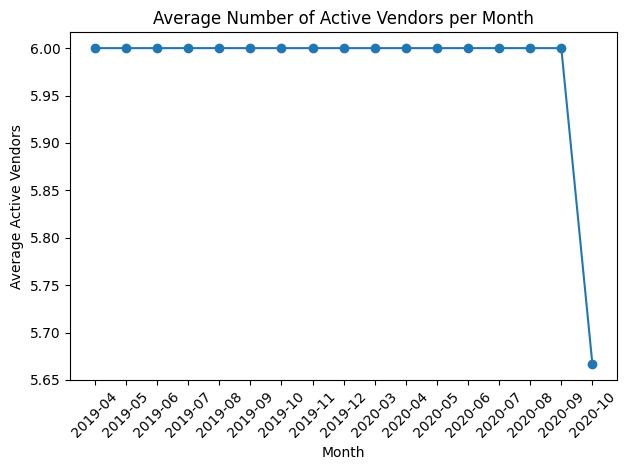

In [12]:


df_active_day["month"] = df_active_day["market_date"].dt.to_period("M")

df_monthly = (
    df_active_day
    .groupby("month")["active_vendors"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(df_monthly["month"].astype(str), df_monthly["active_vendors"], marker='o')
plt.xlabel("Month")
plt.ylabel("Average Active Vendors")
plt.title("Average Number of Active Vendors per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### 3. Which customers contribute the most revenue?

In [13]:
sql = """
SELECT 
    CONCAT(c.customer_first_name, ' ', c.customer_last_name) AS customer_name,
    SUM(cp.quantity * vi.original_price) AS total_spent
FROM customer_purchases cp
JOIN customer c ON cp.customer_id = c.customer_id
JOIN vendor_inventory vi ON cp.product_id = vi.product_id
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 10;
"""

df_top_customer = pd.read_sql(sql, conn)
df_top_customer


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\3008006559.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_customer = pd.read_sql(sql, conn)


,customer_name,total_spent
0,Manuel Diaz,554274.4721
1,Bob Wilson,521204.1527
2,Abigail Harris,520598.0936
3,Richard Paulson,476493.1641
4,Jane Connor,466370.2070
5,Norma Valenzuela,458940.1671
6,Deanna Washington,457845.7360
7,Jack Wise,436437.3836
8,Janet Forbes,408813.3433
9,Betty Bullard,396626.2594


### 5. Are there seasonal patterns in customer purchases?

In [14]:
sql = """
SELECT 
    market_date,
    SUM(quantity) AS total_sales
FROM customer_purchases
GROUP BY market_date
ORDER BY market_date;
"""
df_sales_by_date = pd.read_sql(sql, conn)
df_sales_by_date


C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\1921960686.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_by_date = pd.read_sql(sql, conn)


,market_date,total_sales
0,2019-04-03,45.00
1,2019-04-06,67.00
2,2019-04-10,60.00
3,2019-04-13,45.00
4,2019-04-17,62.00
...,...,...
137,2020-09-26,109.97
138,2020-09-30,110.09
139,2020-10-03,55.00
140,2020-10-07,66.00


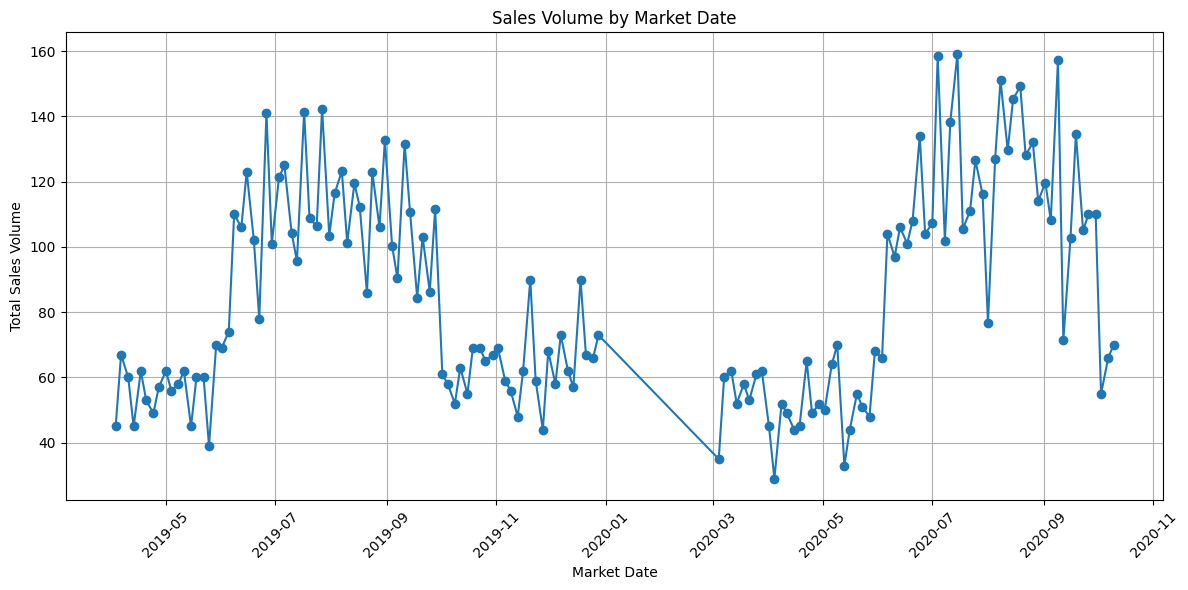

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df_sales_by_date["market_date"], df_sales_by_date["total_sales"], marker='o')
plt.xlabel("Market Date")
plt.ylabel("Total Sales Volume")
plt.title("Sales Volume by Market Date")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Seasonal Patterns in Customer Purchases

Analysis of customer purchases over time indicates clear seasonal patterns:

- **Peak months:** The highest sales volumes are observed between **July and September**, suggesting increased customer activity during late summer.
- **Low months:** Purchase activity is relatively lower during **March to May**, indicating a slower season in spring.
- **Interpretation:** This trend suggests that customers tend to make more purchases during the summer months, possibly due to favorable weather, seasonal events, or special promotions.

These seasonal patterns can help vendors and market organizers plan inventory, staffing, and promotions to better align with customer demand.



In [16]:
conn.close()